# Monte Carlo Sampling Methods
## *How to turn a coin flip into any distribution you want*

At the heart of every Monte Carlo simulation is a deceptively simple question:

> **How do you generate random numbers that follow a specific distribution?**

Computers are good at one thing: generating uniform random numbers between 0 and 1. Everything else — normal distributions, exponential decay, heavy-tailed physics distributions — has to be *constructed* from that primitive.

This notebook builds up the theory and practice of the **Inverse CDF Method** — the most elegant general-purpose solution to this problem. Along the way we'll uncover a beautiful universal result called the **Probability Integral Transform**, and apply everything to the **Breit-Wigner distribution** from particle physics — a distribution so heavy-tailed that its mean is mathematically undefined.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Clean, consistent plot style throughout
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

np.random.seed(42)  # reproducibility

---
## Part 1 — The Probability Integral Transform
### *The universal result that makes everything possible*

Here is a remarkable fact:

> **If X is a continuous random variable with CDF F(x), then the transformed variable R = F(X) is always uniformly distributed on [0, 1] — regardless of what distribution X follows.**

### Why does this work?

The transformation formula for random variables tells us that if R = r(X), the new PDF g(r) is:

$$g(r) = f(x) \cdot \left|\frac{dx}{dr}\right|$$

If we choose r(x) = F(x) — the CDF itself — then:
- $\frac{dr}{dx} = F'(x) = f(x)$ — the derivative of the CDF is the PDF by definition
- So $\frac{dx}{dr} = \frac{1}{f(x)}$

Substituting:
$$g(r) = f(x) \cdot \frac{1}{f(x)} = 1$$

The f(x) terms cancel perfectly. g(r) = 1 is the Uniform(0,1) distribution. Every time. For any distribution.

The CDF acts as a **perfect equaliser** — no matter how peaked, skewed, or heavy-tailed the original distribution, passing it through its own CDF always produces a flat uniform distribution.

Let's verify this visually for three very different distributions.

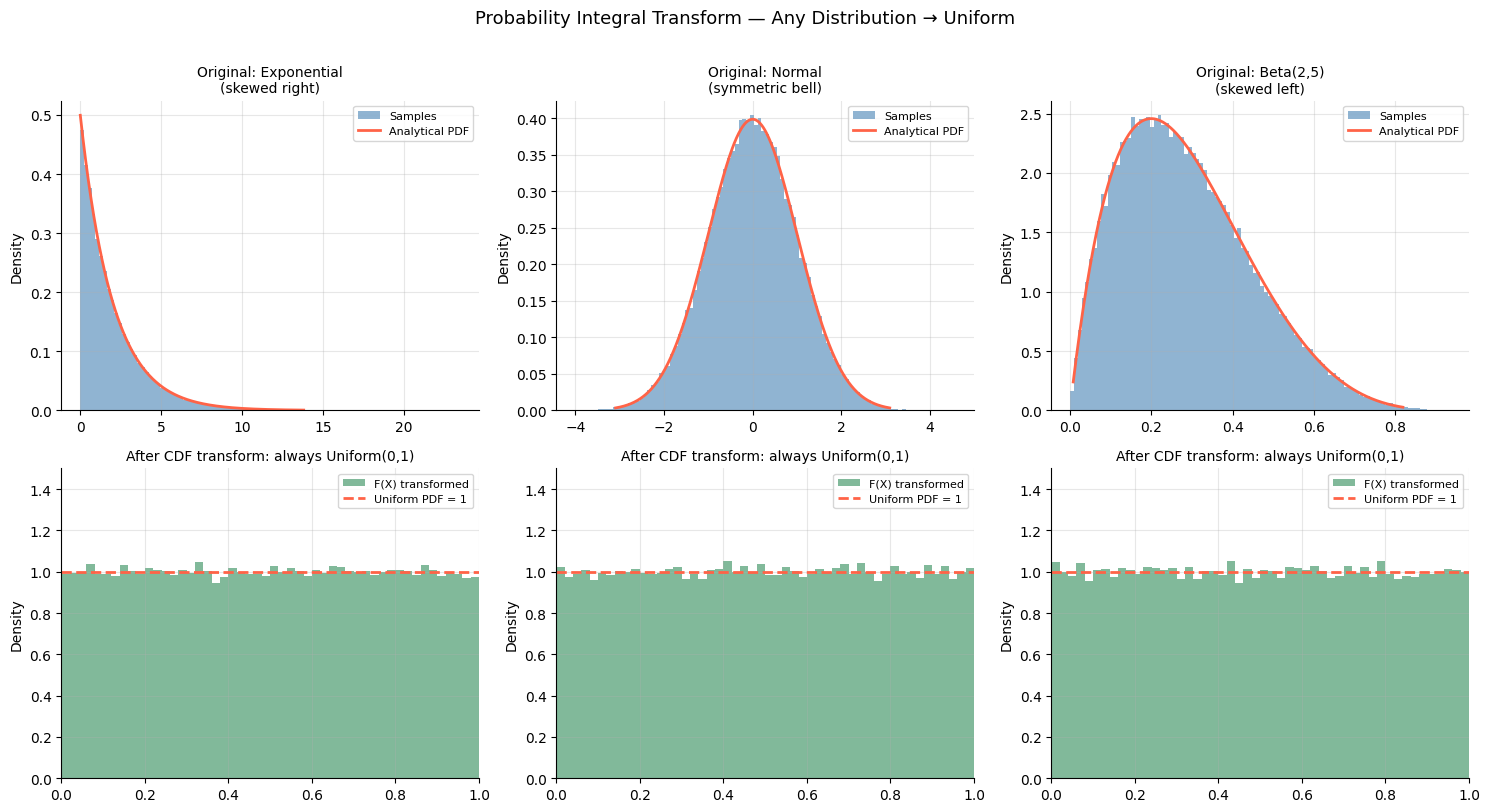

Three completely different distributions — all transformed to Uniform(0,1).
The CDF is a universal equaliser.


In [11]:
N = 100_000  # number of samples

# Three distributions with very different shapes
distributions = {
    'Exponential\n(skewed right)': stats.expon(scale=2),
    'Normal\n(symmetric bell)':    stats.norm(loc=0, scale=1),
    'Beta(2,5)\n(skewed left)':    stats.beta(a=2, b=5),
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for col, (name, dist) in enumerate(distributions.items()):

    # --- Row 1: original distribution samples ---
    samples = dist.rvs(N)
    x_plot = np.linspace(dist.ppf(0.001), dist.ppf(0.999), 500)

    axes[0, col].hist(samples, bins=100, density=True,
                      alpha=0.6, color='steelblue', label='Samples')
    axes[0, col].plot(x_plot, dist.pdf(x_plot), 'tomato', lw=2, label='Analytical PDF')
    axes[0, col].set_title(f'Original: {name}', fontsize=10)
    axes[0, col].set_ylabel('Density')
    axes[0, col].legend(fontsize=8)

    # --- Row 2: pass samples through their own CDF ---
    # This is the Probability Integral Transform: R = F(X)
    # Whatever the distribution, the result should always be Uniform(0,1)
    transformed = dist.cdf(samples)

    axes[1, col].hist(transformed, bins=50, density=True,
                      alpha=0.6, color='seagreen', label='F(X) transformed')
    axes[1, col].axhline(1.0, color='tomato', lw=2, linestyle='--', label='Uniform PDF = 1')
    axes[1, col].set_title(f'After CDF transform: always Uniform(0,1)', fontsize=10)
    axes[1, col].set_ylabel('Density')
    axes[1, col].set_xlim(0, 1)
    axes[1, col].set_ylim(0, 1.5)
    axes[1, col].legend(fontsize=8)

plt.suptitle('Probability Integral Transform — Any Distribution → Uniform', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('probability_integral_transform.png', dpi=150)
plt.show()

print("Three completely different distributions — all transformed to Uniform(0,1).")
print("The CDF is a universal equaliser.")

---
## Part 2 — The Inverse CDF Method
### *Running the transform backwards*

If passing X through F gives Uniform — then passing Uniform through F⁻¹ gives X back.

This is the **Inverse CDF Method** (also called inverse transform sampling):

1. Draw R ~ Uniform(0, 1) — trivial on any computer
2. Compute X = F⁻¹(R) — apply the inverse CDF
3. X is now distributed according to f(x)

The key requirement: you must be able to invert F(x) analytically. For many distributions this works cleanly. For others, numerical inversion is needed.

### The Breit-Wigner Distribution

Originally from particle physics — it describes the mass distribution of unstable resonance particles near their peak energy. Mathematically identical to the Cauchy distribution in statistics.

$$f(x) = \frac{1}{\pi} \frac{\Gamma/2}{\Gamma^2/4 + (x-x_0)^2}$$

Where:
- $x_0$ = peak position (resonance energy)
- $\Gamma$ = full width at half maximum (FWHM) — controls how broad the peak is

### Deriving the Inverse CDF

Integrating the PDF gives the CDF:
$$F(x) = \frac{1}{2} + \frac{1}{\pi}\arctan\left(\frac{x - x_0}{\Gamma/2}\right)$$

Setting R = F(x) and solving for x:
- Subtract 1/2: $R - \frac{1}{2} = \frac{1}{\pi}\arctan\left(\frac{x-x_0}{\Gamma/2}\right)$
- Multiply by π: $\pi(R - \frac{1}{2}) = \arctan\left(\frac{x-x_0}{\Gamma/2}\right)$
- Apply tan: $\tan\left(\pi(R-\frac{1}{2})\right) = \frac{x-x_0}{\Gamma/2}$
- Solve for x:

$$\boxed{x(R) = x_0 + \frac{\Gamma}{2}\tan\left(\pi\left(R - \frac{1}{2}\right)\right)}$$

This is our sampling formula. One line of NumPy.

In [12]:
# Breit-Wigner parameters
x0    = 0.0   # peak position
Gamma = 2.0   # full width at half maximum
N     = 500_000

def breit_wigner_pdf(x, x0, Gamma):
    """Analytical Breit-Wigner probability density function."""
    return (1/np.pi) * (Gamma/2) / ((Gamma/2)**2 + (x - x0)**2)

def breit_wigner_cdf(x, x0, Gamma):
    """Analytical Breit-Wigner cumulative distribution function."""
    return 0.5 + (1/np.pi) * np.arctan((x - x0) / (Gamma/2))

def inverse_cdf_breit_wigner(r, x0, Gamma):
    """
    Inverse CDF of the Breit-Wigner distribution.
    Takes uniform samples r in (0,1) and returns Breit-Wigner samples.
    Derived by inverting F(x) = 0.5 + (1/pi)*arctan((x-x0)/(Gamma/2)).
    """
    return x0 + (Gamma/2) * np.tan(np.pi * (r - 0.5))

# Step 1: generate uniform samples — the raw ingredient
r_uniform = np.random.uniform(0, 1, N)

# Step 2: transform through inverse CDF — one line produces Breit-Wigner samples
x_samples = inverse_cdf_breit_wigner(r_uniform, x0, Gamma)

# Clip extreme tails for plotting — Breit-Wigner has heavy tails that extend very far
# This is purely cosmetic; the samples themselves are unclipped
clip = 20
x_plot_range = np.linspace(-clip, clip, 1000)
x_samples_clipped = x_samples[(x_samples > -clip) & (x_samples < clip)]

print(f"Total samples generated : {N:,}")
print(f"Samples within ±{clip}      : {len(x_samples_clipped):,} ({len(x_samples_clipped)/N:.1%})")
print(f"Samples in tails (|x|>{clip}): {N - len(x_samples_clipped):,} ({(N-len(x_samples_clipped))/N:.1%})")
print(f"\nThose tail samples are real — Breit-Wigner genuinely assigns significant")
print(f"probability to extreme values. We clip only for visual clarity.")

Total samples generated : 500,000
Samples within ±20      : 484,121 (96.8%)
Samples in tails (|x|>20): 15,879 (3.2%)

Those tail samples are real — Breit-Wigner genuinely assigns significant
probability to extreme values. We clip only for visual clarity.


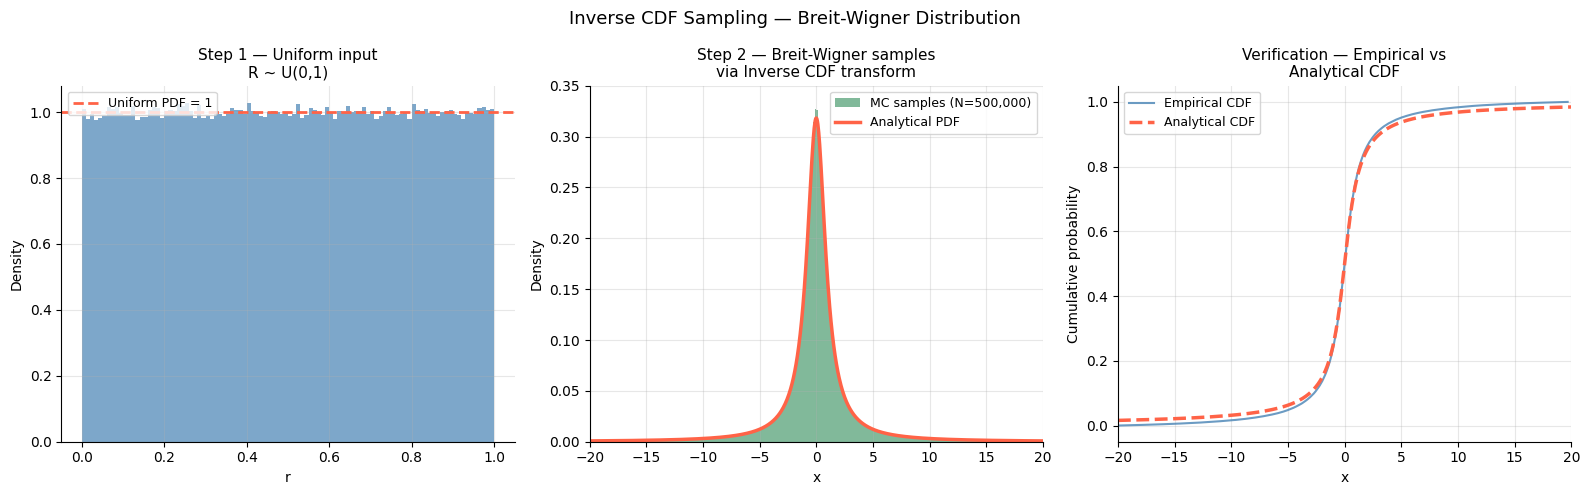

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Panel 1: uniform input samples ---
axes[0].hist(r_uniform, bins=100, density=True,
             alpha=0.7, color='steelblue', edgecolor='none')
axes[0].axhline(1.0, color='tomato', lw=2, linestyle='--', label='Uniform PDF = 1')
axes[0].set_title('Step 1 — Uniform input\nR ~ U(0,1)', fontsize=11)
axes[0].set_xlabel('r')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=9)

# --- Panel 2: MC samples vs analytical PDF ---
axes[1].hist(x_samples_clipped, bins=300, density=True,
             alpha=0.6, color='seagreen', label=f'MC samples (N={N:,})')
axes[1].plot(x_plot_range, breit_wigner_pdf(x_plot_range, x0, Gamma),
             'tomato', lw=2.5, label='Analytical PDF')
axes[1].set_xlim(-clip, clip)
axes[1].set_ylim(0, 0.35)
axes[1].set_title('Step 2 — Breit-Wigner samples\nvia Inverse CDF transform', fontsize=11)
axes[1].set_xlabel('x')
axes[1].set_ylabel('Density')
axes[1].legend(fontsize=9)

# --- Panel 3: verify CDF matches ---
# Sort samples and compute empirical CDF
x_sorted = np.sort(x_samples_clipped)
empirical_cdf = np.arange(1, len(x_sorted)+1) / len(x_sorted)

# Plot every 500th point to keep it manageable
step = 500
axes[2].plot(x_sorted[::step], empirical_cdf[::step],
             'steelblue', lw=1.5, alpha=0.8, label='Empirical CDF')
axes[2].plot(x_plot_range, breit_wigner_cdf(x_plot_range, x0, Gamma),
             'tomato', lw=2.5, linestyle='--', label='Analytical CDF')
axes[2].set_xlim(-clip, clip)
axes[2].set_title('Verification — Empirical vs\nAnalytical CDF', fontsize=11)
axes[2].set_xlabel('x')
axes[2].set_ylabel('Cumulative probability')
axes[2].legend(fontsize=9)

plt.suptitle('Inverse CDF Sampling — Breit-Wigner Distribution', fontsize=13)
plt.tight_layout()
plt.savefig('inverse_cdf_breit_wigner.png', dpi=150)
plt.show()

---
## Part 3 — The Undefined Mean
### *What heavy tails actually mean in practice*

The Breit-Wigner (Cauchy) distribution has a famous property: **its mean is mathematically undefined**.

The integral $\int_{-\infty}^{\infty} x \cdot f(x) \, dx$ does not converge — the tails decay so slowly (as $1/x^2$) that the contribution from extreme values never stops growing.

For a normal distribution, the **Law of Large Numbers** guarantees the sample mean converges to the true mean as N grows. For Breit-Wigner, no such convergence exists.

Let's watch this happen.

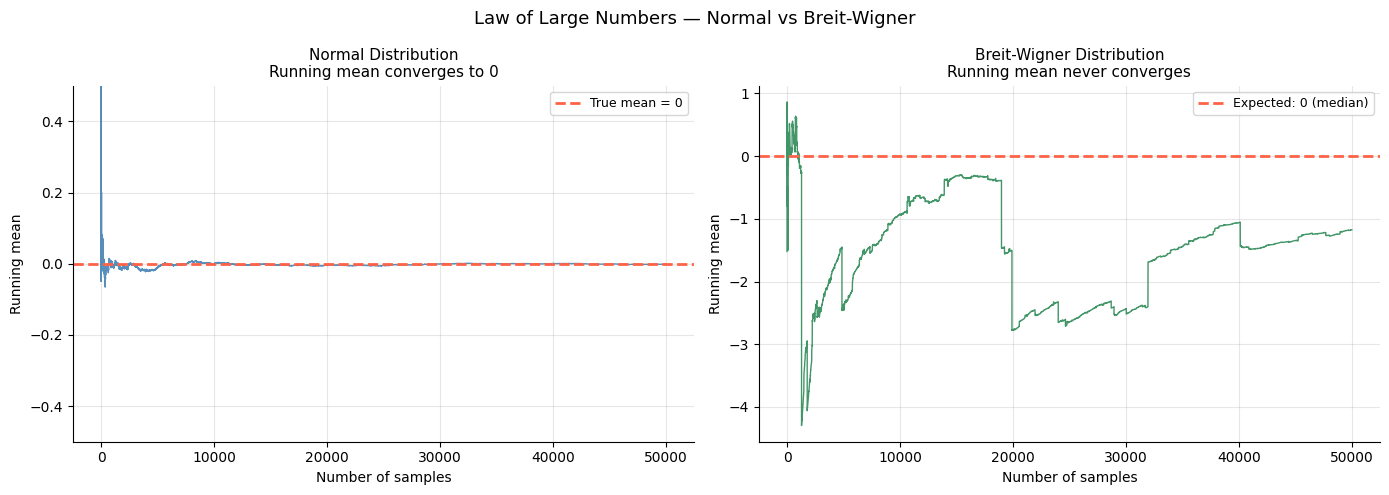

Normal   — final running mean: -0.001345  (true mean = 0.0)
Breit-Wigner — final running mean: -1.175703  (mean is undefined)

The normal mean has settled. The Breit-Wigner mean is still drifting.
Run this cell again — you will get a completely different Breit-Wigner running mean.


In [14]:
N_convergence = 50_000

# Generate fresh samples for convergence analysis
r_fresh = np.random.uniform(0, 1, N_convergence)
bw_samples = inverse_cdf_breit_wigner(r_fresh, x0=0, Gamma=2)
normal_samples = np.random.normal(loc=0, scale=1, size=N_convergence)

# Running mean: mean of first k samples, for each k
# This shows whether the mean is converging as we add more samples
running_mean_bw     = np.cumsum(bw_samples)     / np.arange(1, N_convergence + 1)
running_mean_normal = np.cumsum(normal_samples) / np.arange(1, N_convergence + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sample_indices = np.arange(1, N_convergence + 1)

# Normal distribution — running mean converges
axes[0].plot(sample_indices, running_mean_normal, color='steelblue', lw=1, alpha=0.9)
axes[0].axhline(0, color='tomato', lw=2, linestyle='--', label='True mean = 0')
axes[0].set_title('Normal Distribution\nRunning mean converges to 0', fontsize=11)
axes[0].set_xlabel('Number of samples')
axes[0].set_ylabel('Running mean')
axes[0].set_ylim(-0.5, 0.5)
axes[0].legend(fontsize=9)

# Breit-Wigner — running mean never converges
axes[1].plot(sample_indices, running_mean_bw, color='seagreen', lw=1, alpha=0.9)
axes[1].axhline(0, color='tomato', lw=2, linestyle='--', label='Expected: 0 (median)')
axes[1].set_title('Breit-Wigner Distribution\nRunning mean never converges', fontsize=11)
axes[1].set_xlabel('Number of samples')
axes[1].set_ylabel('Running mean')
axes[1].legend(fontsize=9)

plt.suptitle('Law of Large Numbers — Normal vs Breit-Wigner', fontsize=13)
plt.tight_layout()
plt.savefig('running_mean_convergence.png', dpi=150)
plt.show()

print(f"Normal   — final running mean: {running_mean_normal[-1]:.6f}  (true mean = 0.0)")
print(f"Breit-Wigner — final running mean: {running_mean_bw[-1]:.6f}  (mean is undefined)")
print(f"\nThe normal mean has settled. The Breit-Wigner mean is still drifting.")
print(f"Run this cell again — you will get a completely different Breit-Wigner running mean.")

**What you're seeing:** every time you run the Breit-Wigner simulation, the running mean takes a different path and never stabilises. An occasional extreme sample from the heavy tail sends the mean jumping to a completely new value, erasing any convergence that had built up.

The median, however, does converge — it is not affected by extreme values and reliably approaches 0 (= x₀).

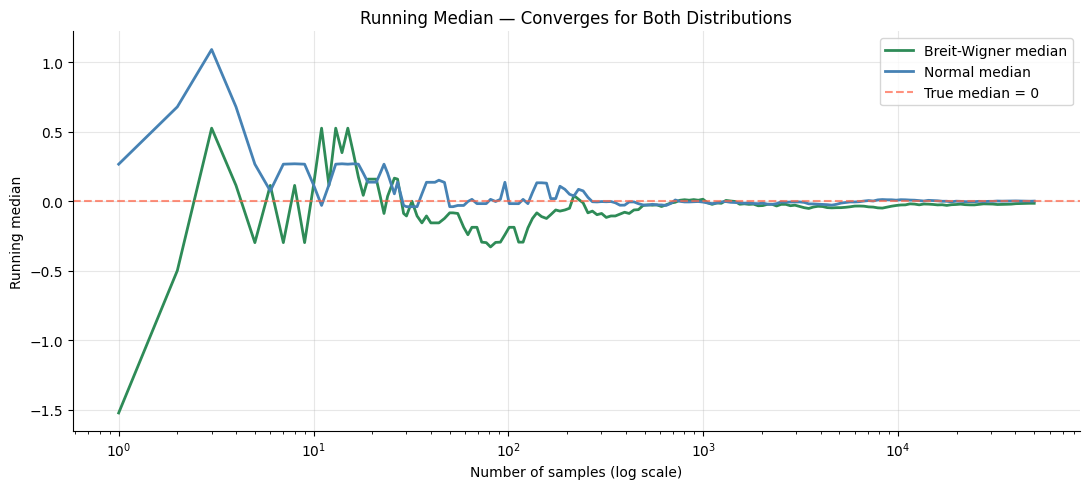

The median converges reliably for both distributions.
For heavy-tailed distributions, the median is a more robust measure of centre than the mean.


In [16]:
# Running median — converges even for Breit-Wigner
# We compute it over logarithmically spaced checkpoints for efficiency
checkpoints = np.unique(np.logspace(0, np.log10(N_convergence), 200).astype(int))

running_median_bw     = [np.median(bw_samples[:k])     for k in checkpoints]
running_median_normal = [np.median(normal_samples[:k]) for k in checkpoints]

fig, ax = plt.subplots(figsize=(11, 5))
ax.semilogx(checkpoints, running_median_bw,     color='seagreen',  lw=2, label='Breit-Wigner median')
ax.semilogx(checkpoints, running_median_normal, color='steelblue', lw=2, label='Normal median')
ax.axhline(0, color='tomato', lw=1.5, linestyle='--', alpha=0.7, label='True median = 0')
ax.set_title('Running Median — Converges for Both Distributions', fontsize=12)
ax.set_xlabel('Number of samples (log scale)')
ax.set_ylabel('Running median')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('running_median_convergence.png', dpi=150)
plt.show()

print("The median converges reliably for both distributions.")
print("For heavy-tailed distributions, the median is a more robust measure of centre than the mean.")

---
## Summary

| Concept | What was shown |
|---------|---------------|
| Probability Integral Transform | Any distribution passed through its own CDF becomes Uniform(0,1) |
| Inverse CDF Method | Uniform samples passed through F⁻¹ follow the target distribution |
| Breit-Wigner sampling | One-line inverse CDF formula produces exact samples from a physics distribution |
| Heavy tails | Sample mean never converges — median does |

**Real-world relevance:** The inverse CDF method is a foundational tool in scientific computing, quantitative finance, and engineering simulation — anywhere you need to generate samples from non-standard distributions efficiently. The heavy-tail insight has direct applications in risk modelling, where assuming normality can catastrophically underestimate the probability of extreme events.